#Mount Google Drive

In [ ]:
"/content/drive/MyDrive/..."
"data/solar_panel_rectification_and_maintenance.csv"

# Set your Google Drive folder path here
DRIVE_FOLDER = "/content/drive/MyDrive/SolarPV_Rectification"

import os
os.makedirs(DRIVE_FOLDER, exist_ok=True)
print(f"Drive mounted. Working folder: {DRIVE_FOLDER}")

: 

#Install/Import Libraries

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


Load Dataset from Google Drive

In [3]:
DATASET_PATH = f"{DRIVE_FOLDER}/solar_panel_rectification_and_maintenance.csv"

df = pd.read_csv(DATASET_PATH)
df["Timestamp"]  = pd.to_datetime(df["Timestamp"])
df               = df.sort_values("Timestamp").reset_index(drop=True)
df["String_Num"] = df["Fault_Location"].str.extract(r"String-(\d+)").astype(int)
df["Panel_Num"]  = df["Fault_Location"].str.extract(r"Panel-(\d+)").astype(int)

print(f"Dataset loaded from: {DATASET_PATH}")
print(f"  Total records  : {len(df)}")
print(f"  Date range     : {df['Timestamp'].min().date()} → {df['Timestamp'].max().date()}")
print(f"  Columns        : {df.columns.tolist()}")
print(f"\nSample:")
print(df[["Fault_Type", "Severity_Level", "Rectification_Action",
          "Repair_Cost", "Downtime_Hours"]].head(5))

Dataset loaded from: /content/drive/MyDrive/SolarPV_Rectification/solar_panel_rectification_and_maintenance.csv
  Total records  : 6000
  Date range     : 2023-01-01 → 2023-07-28
  Columns        : ['Fault_Type', 'Fault_Location', 'Severity_Level', 'Module_Age_Years', 'Rectification_Action', 'Previous_Rectification_Action', 'Irradiance', 'Weather_Condition', 'Timestamp', 'String_Num', 'Panel_Num', 'Repair_Cost', 'Downtime_Hours', 'Energy_Loss_Cost', 'Total_Cost']

Sample:
      Fault_Type Severity_Level Rectification_Action  Repair_Cost  \
0        Hotspot           High       Replace Module       532.68   
1   Open Circuit           High       Replace Wiring       161.29   
2      Shadowing           High   Remove Obstruction        50.51   
3  Short Circuit         Medium         Replace Fuse        55.91   
4   Open Circuit            Low   Tighten Connection        40.21   

   Downtime_Hours  
0            5.25  
1            1.53  
2            0.48  
3            0.55  
4       

Building Cost and Downtime Lookup for getting the best recommendation

In [4]:
action_records = {}

for action, grp in df.groupby("Rectification_Action"):
    action_records[action] = {
        "costs":     grp["Repair_Cost"].values,
        "downtimes": grp["Downtime_Hours"].values,
        "cost_mean": grp["Repair_Cost"].mean(),
        "down_mean": grp["Downtime_Hours"].mean(),
        "cost_std":  grp["Repair_Cost"].std(),
        "down_std":  grp["Downtime_Hours"].std(),
        "count":     len(grp),
    }

print(f"  {'Action':<28} {'Records':>7}  {'Avg Cost':>10}  {'Avg Downtime':>13}")
print("  " + "─" * 64)
for a, v in sorted(action_records.items(), key=lambda x: x[1]["cost_mean"]):
    print(f"  {a:<28} {v['count']:>7}  ${v['cost_mean']:>9.2f}  {v['down_mean']:>10.2f} hrs")

  Action                       Records    Avg Cost   Avg Downtime
  ────────────────────────────────────────────────────────────────
  Clean Panel                      339  $    30.14        0.30 hrs
  Tighten Connection               300  $    40.30        0.50 hrs
  Remove Obstruction               727  $    50.07        0.50 hrs
  Replace Fuse                     392  $    59.81        0.50 hrs
  Inspect Junction Box             399  $    69.74        1.00 hrs
  Inspect Cells                    458  $    84.82        0.99 hrs
  Replace Connector                295  $    89.93        0.99 hrs
  Adjust Tilt                      247  $   120.24        2.00 hrs
  Replace Wiring                   783  $   149.57        2.00 hrs
  Reinstall Module                 279  $   200.52        2.99 hrs
  Replace Panel Section            361  $   320.08        4.00 hrs
  Replace Module                  1420  $   519.95        6.00 hrs


Defining Reward Function

In [5]:
# Normalisation constants (from real data)
MAX_COST = max(v["cost_mean"] for v in action_records.values())
MAX_DOWN = max(v["down_mean"] for v in action_records.values())

def get_reward(chosen_action, true_action, rng):
    """
    Reward = (+10 if correct) - (3 x normalised cost) - (2 x normalised downtime)

    - Correctness is weighted highest so the agent stays accurate
    - Cost and downtime act as tiebreakers between equally correct options
    - Cost and downtime values are sampled from REAL dataset records
    """
    correct = 1.0 if chosen_action == true_action else 0.0
    idx     = rng.integers(0, action_records[chosen_action]["count"])
    cost_n  = action_records[chosen_action]["costs"][idx]     / MAX_COST
    down_n  = action_records[chosen_action]["downtimes"][idx] / MAX_DOWN
    return (10.0 * correct) - (3.0 * cost_n) - (2.0 * down_n)

print("Reward function defined.")
print(f"  MAX_COST : ${MAX_COST:.2f}  (normalisation constant)")
print(f"  MAX_DOWN : {MAX_DOWN:.2f} hrs (normalisation constant)")

Reward function defined.
  MAX_COST : $519.95  (normalisation constant)
  MAX_DOWN : 6.00 hrs (normalisation constant)


Applying Ambiguity Rules and Noice to Training Labels

In [6]:
# Same fault + severity can have different valid actions
# depending on context (age, irradiance, weather, location).
# 10% plausible noise simulates technician judgment variation.

def assign_with_ambiguity(row, rng):
    ft=row["Fault_Type"]; sev=row["Severity_Level"]; age=row["Module_Age_Years"]
    irr=row["Irradiance"]; wx=row["Weather_Condition"]; sn=row["String_Num"]; pn=row["Panel_Num"]
    if ft=="Open Circuit":
        if sev=="Low":
            if age>=10 and sn>=8: return "Replace Wiring"
            if 7<=age<=9 and 6<=sn<=7: return rng.choice(["Tighten Connection","Replace Wiring"],p=[0.5,0.5])
            return "Tighten Connection"
        if sev=="Medium":
            if irr>800: return "Replace Wiring"
            if 650<=irr<=800: return rng.choice(["Replace Connector","Replace Wiring"],p=[0.6,0.4])
            return "Replace Connector"
        if sev=="High":
            if wx=="Rainy" and pn>=15: return "Inspect Junction Box"
            if wx=="Rainy" and 10<=pn<=14: return rng.choice(["Replace Wiring","Inspect Junction Box"],p=[0.55,0.45])
            return "Replace Wiring"
        if sev=="Critical": return "Replace Module"
    if ft=="Short Circuit":
        if sev=="Low":
            if wx=="Rainy" and age>=8: return "Replace Fuse"
            if wx=="Rainy" and 5<=age<=7: return rng.choice(["Inspect Junction Box","Replace Fuse"],p=[0.55,0.45])
            return "Inspect Junction Box"
        if sev=="Medium":
            if age<=3: return rng.choice(["Replace Fuse","Inspect Junction Box"],p=[0.65,0.35])
            return "Replace Fuse"
        if sev=="High":
            if age>=12: return "Replace Module"
            if 9<=age<=11: return rng.choice(["Replace Wiring","Replace Module"],p=[0.6,0.4])
            return "Replace Wiring"
        if sev=="Critical": return "Replace Module"
    if ft=="Hotspot":
        if sev=="Low":
            if irr>750: return "Inspect Cells"
            if 550<=irr<=750: return rng.choice(["Clean Panel","Inspect Cells"],p=[0.55,0.45])
            return "Clean Panel"
        if sev=="Medium":
            if irr>850 and age>=8: return "Replace Panel Section"
            if irr>850 and 5<=age<=7: return rng.choice(["Inspect Cells","Replace Panel Section"],p=[0.5,0.5])
            if 700<=irr<=850 and age>=8: return rng.choice(["Inspect Cells","Replace Panel Section"],p=[0.6,0.4])
            return "Inspect Cells"
        if sev=="High":
            if pn>=15: return "Replace Module"
            if 11<=pn<=14: return rng.choice(["Replace Panel Section","Replace Module"],p=[0.6,0.4])
            return "Replace Panel Section"
        if sev=="Critical": return "Replace Module"
    if ft=="Shadowing":
        if sev=="Low":
            if wx in ["Cloudy","Rainy"]: return "Remove Obstruction"
            if wx=="Sunny" and irr<400: return rng.choice(["Clean Panel","Remove Obstruction"],p=[0.5,0.5])
            return "Clean Panel"
        if sev=="Medium":
            if age<=3 and irr<350: return rng.choice(["Remove Obstruction","Adjust Tilt"],p=[0.6,0.4])
            return "Remove Obstruction"
        if sev=="High":
            if irr<400: return "Remove Obstruction"
            if 400<=irr<=600: return rng.choice(["Adjust Tilt","Remove Obstruction"],p=[0.55,0.45])
            return "Adjust Tilt"
        if sev=="Critical":
            if age>=10: return "Replace Module"
            if 7<=age<=9: return rng.choice(["Reinstall Module","Replace Module"],p=[0.55,0.45])
            return "Reinstall Module"
    return row["Rectification_Action"]

PLAUSIBLE_NEIGHBOURS = {
    "Tighten Connection":   ["Replace Connector","Replace Wiring"],
    "Replace Connector":    ["Tighten Connection","Replace Wiring","Inspect Junction Box"],
    "Replace Wiring":       ["Replace Connector","Inspect Junction Box","Replace Module"],
    "Inspect Junction Box": ["Replace Connector","Replace Fuse","Replace Wiring"],
    "Replace Fuse":         ["Inspect Junction Box","Replace Wiring","Replace Connector"],
    "Replace Module":       ["Replace Panel Section","Replace Wiring","Reinstall Module"],
    "Replace Panel Section":["Replace Module","Inspect Cells","Clean Panel"],
    "Inspect Cells":        ["Clean Panel","Replace Panel Section","Replace Module"],
    "Clean Panel":          ["Inspect Cells","Remove Obstruction"],
    "Remove Obstruction":   ["Clean Panel","Adjust Tilt","Reinstall Module"],
    "Adjust Tilt":          ["Remove Obstruction","Reinstall Module"],
    "Reinstall Module":     ["Replace Module","Adjust Tilt","Remove Obstruction"],
}

rng_aug   = np.random.default_rng(42)
rng_noise = np.random.default_rng(99)

df["Rectification_Action"] = df.apply(lambda r: assign_with_ambiguity(r, rng_aug), axis=1)
df["Rectification_Action"] = df["Rectification_Action"].apply(
    lambda a: rng_noise.choice(PLAUSIBLE_NEIGHBOURS.get(a, [a]))
              if rng_noise.random() < 0.10 else a
)

print("Ambiguity rules and noise applied to labels.")
print(f"  Unique actions in training data: {df['Rectification_Action'].nunique()}")
print(df["Rectification_Action"].value_counts())


Ambiguity rules and noise applied to labels.
  Unique actions in training data: 12
Rectification_Action
Replace Module           1426
Replace Wiring            772
Remove Obstruction        719
Inspect Cells             455
Replace Fuse              397
Inspect Junction Box      397
Replace Panel Section     367
Clean Panel               345
Tighten Connection        309
Replace Connector         289
Reinstall Module          278
Adjust Tilt               246
Name: count, dtype: int64


Defining Features and Train/Test Split

In [7]:
PRIMARY_CAT   = ["Fault_Type", "Severity_Level"]
PRIMARY_NUM   = ["String_Num", "Panel_Num"]
SECONDARY_CAT = ["Weather_Condition"]
SECONDARY_NUM = ["Irradiance", "Module_Age_Years"]
ALL_FEATURES  = PRIMARY_CAT + PRIMARY_NUM + SECONDARY_CAT + SECONDARY_NUM
TARGET        = "Rectification_Action"

# Temporal split — train on past, test on future (80/20)
split_idx = int(len(df) * 0.8)
X_train = df.iloc[:split_idx][ALL_FEATURES]
y_train = df.iloc[:split_idx][TARGET]
X_test  = df.iloc[split_idx:][ALL_FEATURES]
y_test  = df.iloc[split_idx:][TARGET]

print(f"Train size : {len(X_train)} records ({df['Timestamp'].iloc[split_idx-1].date()} and before)")
print(f"Test size  : {len(X_test)}  records ({df['Timestamp'].iloc[split_idx].date()} and after)")
print(f"Features   : {ALL_FEATURES}")

Train size : 4800 records (2023-06-17 and before)
Test size  : 1200  records (2023-06-17 and after)
Features   : ['Fault_Type', 'Severity_Level', 'String_Num', 'Panel_Num', 'Weather_Condition', 'Irradiance', 'Module_Age_Years']


#Random Forest Model Training (Getting 3 rectification actions)

In [8]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), PRIMARY_CAT + SECONDARY_CAT),
    ("num", "passthrough", PRIMARY_NUM + SECONDARY_NUM)
])

rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf",  RandomForestClassifier(
        n_estimators    = 300,
        max_depth       = 12,
        min_samples_split = 10,
        min_samples_leaf  = 5,
        class_weight    = "balanced",
        random_state    = 42,
        n_jobs          = -1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf       = rf_pipeline.predict(X_test)
rf_baseline_acc = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest trained.")
print(f"  Test Accuracy : {rf_baseline_acc:.4f} ({rf_baseline_acc:.2%})")

Random Forest trained.
  Test Accuracy : 0.8425 (84.25%)


Classification Report, Confusion Matrix and Feature Importance

Random Forest — Classification Report

                       precision    recall  f1-score   support

          Adjust Tilt       0.81      0.84      0.82        50
          Clean Panel       0.78      0.79      0.78        76
        Inspect Cells       0.80      0.86      0.83        86
 Inspect Junction Box       0.88      0.77      0.82        82
     Reinstall Module       0.74      0.67      0.70        48
   Remove Obstruction       0.89      0.90      0.89       144
    Replace Connector       0.80      0.82      0.81        65
         Replace Fuse       0.87      0.96      0.91        72
       Replace Module       0.88      0.89      0.88       289
Replace Panel Section       0.81      0.72      0.77        79
       Replace Wiring       0.82      0.79      0.80       141
   Tighten Connection       0.83      0.96      0.89        68

             accuracy                           0.84      1200
            macro avg       0.83      0.83      0.83      1200
         weigh

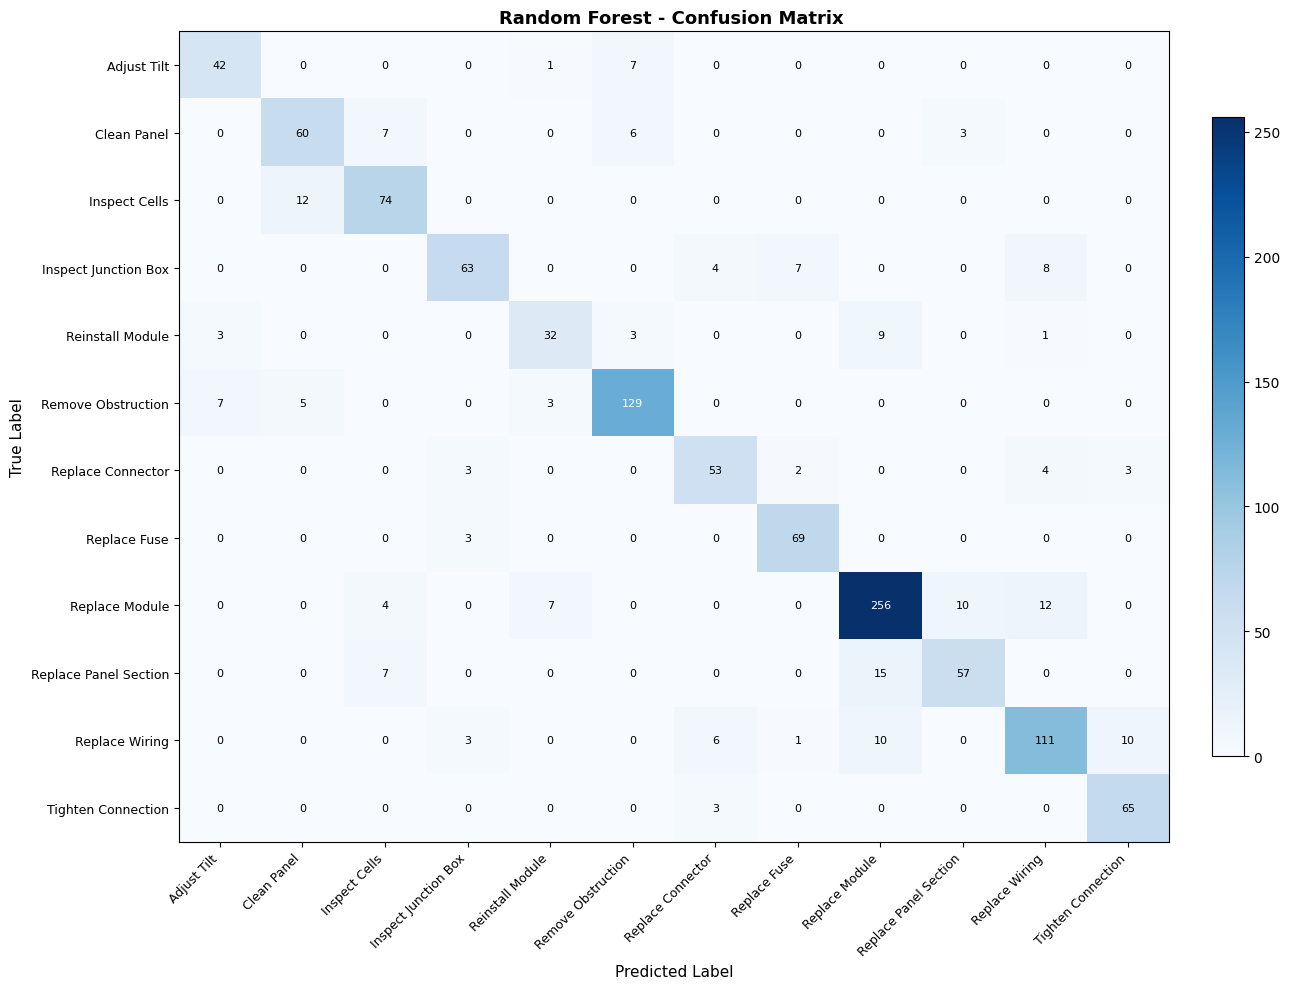

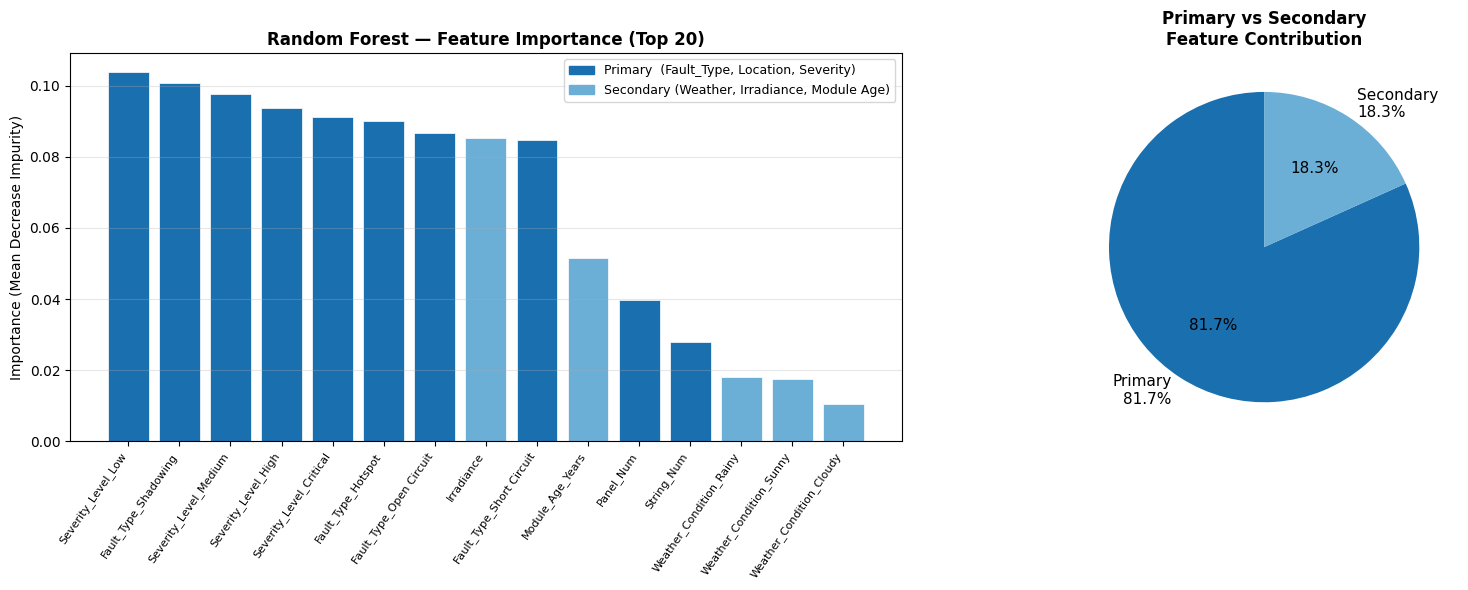

  Primary features   : 81.7%
  Secondary features : 18.3%


In [9]:
#Classification Report
print("Random Forest — Classification Report\n")
print(classification_report(y_test, y_pred_rf))

#Confusion Matrix
rf_classes = rf_pipeline.classes_
cm_rf      = confusion_matrix(y_test, y_pred_rf, labels=rf_classes)

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(cm_rf, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
ax.set_xticks(range(len(rf_classes)))
ax.set_xticklabels(rf_classes, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(rf_classes)))
ax.set_yticklabels(rf_classes, fontsize=9)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.set_title(f"Random Forest - Confusion Matrix ",
             fontsize=13, fontweight="bold")
thresh = cm_rf.max() / 2
for i in range(len(rf_classes)):
    for j in range(len(rf_classes)):
        ax.text(j, i, cm_rf[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm_rf[i, j] > thresh else "black")
plt.tight_layout()
plt.show()


#Feature Importance
clf_rf      = rf_pipeline.named_steps["clf"]
importances = clf_rf.feature_importances_

ohe         = rf_pipeline.named_steps["prep"].transformers_[0][1]
cat_names   = list(ohe.get_feature_names_out(PRIMARY_CAT + SECONDARY_CAT))
all_names   = cat_names + PRIMARY_NUM + SECONDARY_NUM

PRIMARY_SET = {"Fault_Type", "Severity_Level", "String_Num", "Panel_Num"}

def feature_group(name):
    for p in PRIMARY_SET:
        if name.startswith(p): return "primary"
    return "secondary"

colors_fi  = ["#1a6faf" if feature_group(n) == "primary" else "#6baed6" for n in all_names]
sorted_fi  = np.argsort(importances)[::-1]
top20      = sorted_fi[:20]

pri_imp = sum(importances[i] for i, n in enumerate(all_names) if feature_group(n) == "primary")
sec_imp = sum(importances[i] for i, n in enumerate(all_names) if feature_group(n) == "secondary")

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

ax = axes[0]
ax.bar(range(len(top20)), importances[top20],
       color=[colors_fi[i] for i in top20], edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(top20)))
ax.set_xticklabels([all_names[i] for i in top20], rotation=55, ha="right", fontsize=8)
ax.set_ylabel("Importance (Mean Decrease Impurity)", fontsize=10)
ax.set_title("Random Forest — Feature Importance (Top 20)", fontsize=12, fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color="#1a6faf", label="Primary  (Fault_Type, Location, Severity)"),
    mpatches.Patch(color="#6baed6", label="Secondary (Weather, Irradiance, Module Age)"),
], fontsize=9)
ax.grid(axis="y", alpha=0.3)

ax2 = axes[1]
ax2.pie([pri_imp, sec_imp],
        labels=[f"Primary\n{pri_imp*100:.1f}%", f"Secondary\n{sec_imp*100:.1f}%"],
        colors=["#1a6faf", "#6baed6"], autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 11})
ax2.set_title("Primary vs Secondary\nFeature Contribution", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()
print(f"  Primary features   : {pri_imp*100:.1f}%")
print(f"  Secondary features : {sec_imp*100:.1f}%")


Pre-computing the Top 3 Recommendation Actions Predicted

In [10]:
classes     = rf_pipeline.classes_
train_probs = rf_pipeline.predict_proba(X_train)
test_probs  = rf_pipeline.predict_proba(X_test)

train_top3  = [[classes[j] for j in np.argsort(p)[-3:][::-1]] for p in train_probs]
test_top3   = [[classes[j] for j in np.argsort(p)[-3:][::-1]] for p in test_probs]

train_ft    = X_train["Fault_Type"].values
train_sev   = X_train["Severity_Level"].values
test_ft     = X_test["Fault_Type"].values
test_sev    = X_test["Severity_Level"].values

print("RF top-3 predictions pre-computed for all train and test records.")
print(f"  Example (first test record):")
print(f"    Fault : {test_ft[0]} | Severity : {test_sev[0]}")
print(f"    Top-3 : {test_top3[0]}")

RF top-3 predictions pre-computed for all train and test records.
  Example (first test record):
    Fault : Short Circuit | Severity : Medium
    Top-3 : ['Replace Fuse', np.str_('Inspect Junction Box'), 'Replace Connector']


#Train Q-Learning (RL) Agent

In [11]:
# STATE  = (Fault_Type, Severity, RF_top1, RF_top2, RF_top3)
# ACTION = one of the 3 RF-recommended actions
# REWARD = sampled from real Repair_Cost + Downtime_Hours
#
# ε-greedy strategy:
#   Episode 1  → ε=1.0 (fully random, explore all options)
#   Episode 15 → ε=0.05 (mostly greedy, exploit learned Q-values)

Q          = {}    # Q-table: {(state, action): Q-value}
LR         = 0.3   # learning rate
N_EPISODES = 15    # passes over training data
n_train    = len(X_train)
rng        = np.random.default_rng(42)

episode_rewards = []
episode_accs    = []

print("Training Q-Learning Agent...")
print(f"  Reward source : Repair_Cost + Downtime_Hours")
print(f"  Records used  : {sum(v['count'] for v in action_records.values())}")
print(f"  Episodes      : {N_EPISODES}  |  LR: {LR}\n")
print(f"  {'Episode':>8}  {'ε':>6}  {'Avg Reward':>12}  {'Train Acc':>10}")
print("  " + "─" * 44)

for ep in range(N_EPISODES):
    # Linear decay: ε = 1.0 → 0.05 across episodes
    epsilon = max(0.05, 1.0 - (1.0 - 0.05) * ep / N_EPISODES)
    ep_r = 0
    ep_c = 0

    for i in rng.permutation(n_train):
        top3       = train_top3[i]
        true_label = y_train.iloc[i]
        state      = (train_ft[i], train_sev[i], top3[0], top3[1], top3[2])

        # ε-greedy action selection
        if rng.random() < epsilon:
            action = rng.choice(top3)                           # explore
        else:
            q_vals = {a: Q.get((state, a), 0.0) for a in top3}
            action = max(q_vals, key=q_vals.get)                # exploit

        # Reward from real dataset records
        reward  = get_reward(action, true_label, rng)
        ep_r   += reward
        ep_c   += int(action == true_label)

        # Q-value update
        old_q = Q.get((state, action), 0.0)
        Q[(state, action)] = old_q + LR * (reward - old_q)

    episode_rewards.append(ep_r / n_train)
    episode_accs.append(ep_c / n_train)
    print(f"  {ep+1:>8}  {epsilon:>6.3f}  {ep_r/n_train:>12.4f}  {ep_c/n_train:>10.4f}")

print("\n  Q-Learning Training Complete")
print(f"  Q-table entries learned: {len(Q)}")

Training Q-Learning Agent...
  Reward source : Repair_Cost + Downtime_Hours
  Records used  : 6000
  Episodes      : 15  |  LR: 0.3

   Episode       ε    Avg Reward   Train Acc
  ────────────────────────────────────────────
         1   1.000        1.5450      0.3373
         2   0.937        1.8315      0.3652
         3   0.873        2.0672      0.3900
         4   0.810        2.5646      0.4423
         5   0.747        2.7951      0.4635
         6   0.683        3.0325      0.4892
         7   0.620        3.4225      0.5283
         8   0.557        3.8155      0.5677
         9   0.493        4.1171      0.5985
        10   0.430        4.4985      0.6367
        11   0.367        4.7334      0.6671
        12   0.303        4.9910      0.6910
        13   0.240        5.4616      0.7379
        14   0.177        5.7179      0.7646
        15   0.113        6.0928      0.8042

  Q-Learning Training Complete
  Q-table entries learned: 455


RL Inference on Test Set

In [12]:
rl_preds      = []
rf_preds      = []
total_cost    = 0
total_down    = 0
rf_total_cost = 0
rf_total_down = 0

for i in range(len(X_test)):
    top3  = test_top3[i]
    state = (test_ft[i], test_sev[i], top3[0], top3[1], top3[2])
    q_vals = {a: Q.get((state, a), 0.0) for a in top3}

    # If state was never seen in training → fall back to RF top-1
    if all(v == 0.0 for v in q_vals.values()):
        rl_action = top3[0]
    else:
        rl_action = max(q_vals, key=q_vals.get)

    rl_preds.append(rl_action)
    rf_preds.append(top3[0])

    # Use mean cost & downtime from real dataset for reporting
    total_cost    += action_records[rl_action]["cost_mean"]
    total_down    += action_records[rl_action]["down_mean"]
    rf_total_cost += action_records[top3[0]]["cost_mean"]
    rf_total_down += action_records[top3[0]]["down_mean"]

rl_acc = accuracy_score(y_test, rl_preds)
rf_acc = accuracy_score(y_test, rf_preds)
n      = len(X_test)

print(f"Inference complete on {n} test records.\n")
print(f"  {'METRIC':<40} {'RF ONLY':>8}  {'RF+RL':>8}")
print("  " + "─" * 58)
print(f"  {'Accuracy':<40} {rf_acc:>8.2%}  {rl_acc:>8.2%}")
print(f"  {'Total Repair Cost ($)':<40} {rf_total_cost:>8,.0f}  {total_cost:>8,.0f}")
print(f"  {'Cost Saved ($)':<40} {'—':>8}  {rf_total_cost-total_cost:>8,.0f}")
print(f"  {'Total Downtime (hrs)':<40} {rf_total_down:>8.1f}  {total_down:>8.1f}")
print(f"  {'Downtime Saved (hrs)':<40} {'—':>8}  {rf_total_down-total_down:>8.1f}")
print(f"  {'Avg Cost per Job ($)':<40} {rf_total_cost/n:>8.2f}  {total_cost/n:>8.2f}")
print(f"  {'Avg Downtime per Job (hrs)':<40} {rf_total_down/n:>8.2f}  {total_down/n:>8.2f}")

Inference complete on 1200 test records.

  METRIC                                    RF ONLY     RF+RL
  ──────────────────────────────────────────────────────────
  Accuracy                                   84.25%    83.75%
  Total Repair Cost ($)                     244,615   244,026
  Cost Saved ($)                                  —       590
  Total Downtime (hrs)                       2926.3    2919.9
  Downtime Saved (hrs)                            —       6.4
  Avg Cost per Job ($)                       203.85    203.35
  Avg Downtime per Job (hrs)                   2.44      2.43


RL Classification Report, Training Convergence, Cost and DownTime Comparision and Confusion Matrix

RL Model — Classification Report

                       precision    recall  f1-score   support

          Adjust Tilt       0.82      0.84      0.83        50
          Clean Panel       0.76      0.79      0.77        76
        Inspect Cells       0.80      0.86      0.83        86
 Inspect Junction Box       0.88      0.77      0.82        82
     Reinstall Module       0.74      0.67      0.70        48
   Remove Obstruction       0.89      0.90      0.89       144
    Replace Connector       0.79      0.82      0.80        65
         Replace Fuse       0.87      0.96      0.91        72
       Replace Module       0.88      0.88      0.88       289
Replace Panel Section       0.80      0.70      0.74        79
       Replace Wiring       0.79      0.79      0.79       141
   Tighten Connection       0.86      0.91      0.89        68

             accuracy                           0.84      1200
            macro avg       0.82      0.82      0.82      1200
         weighted a

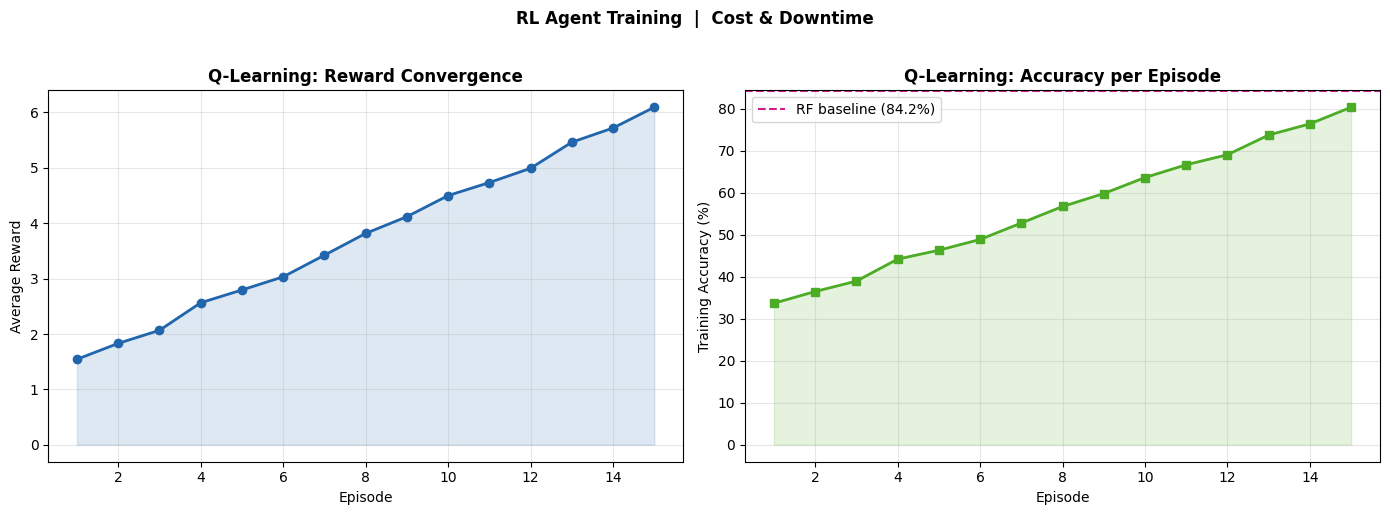

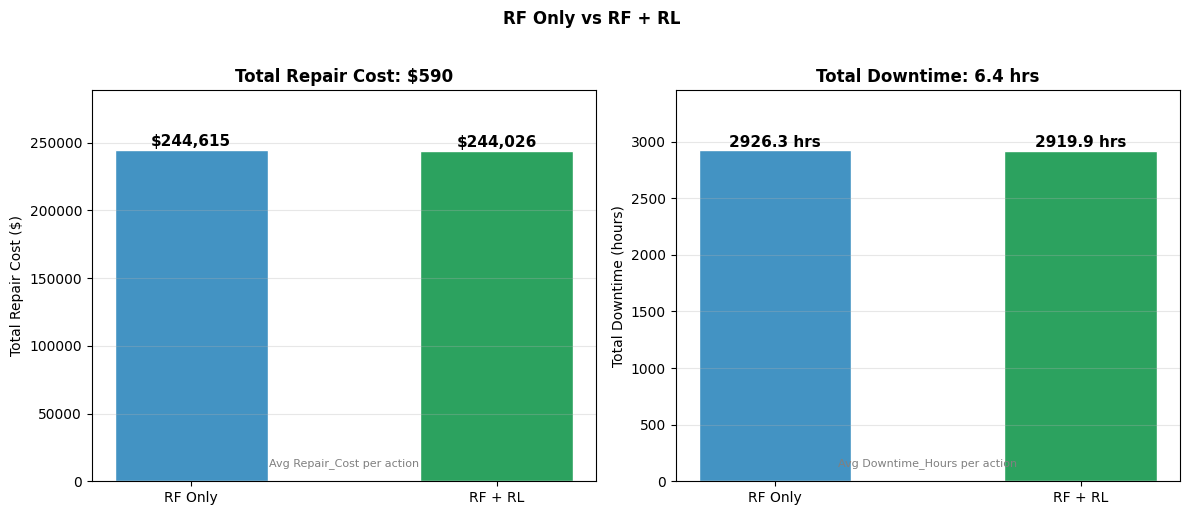

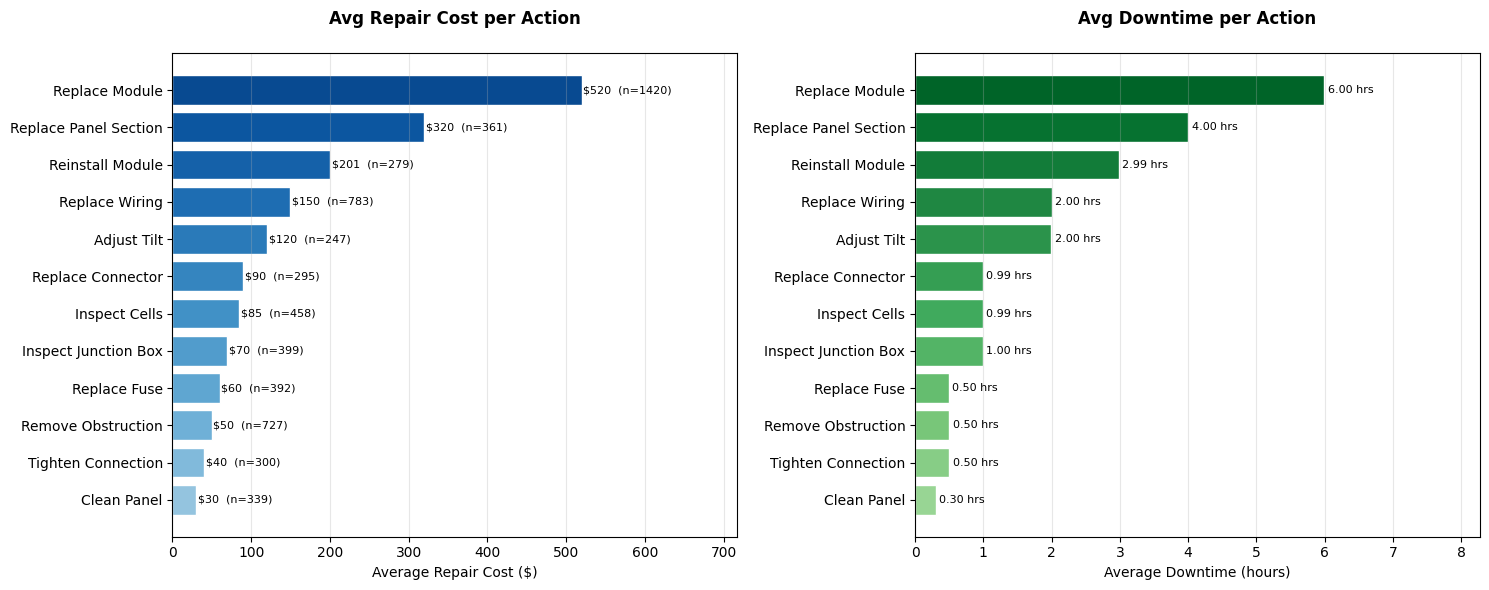

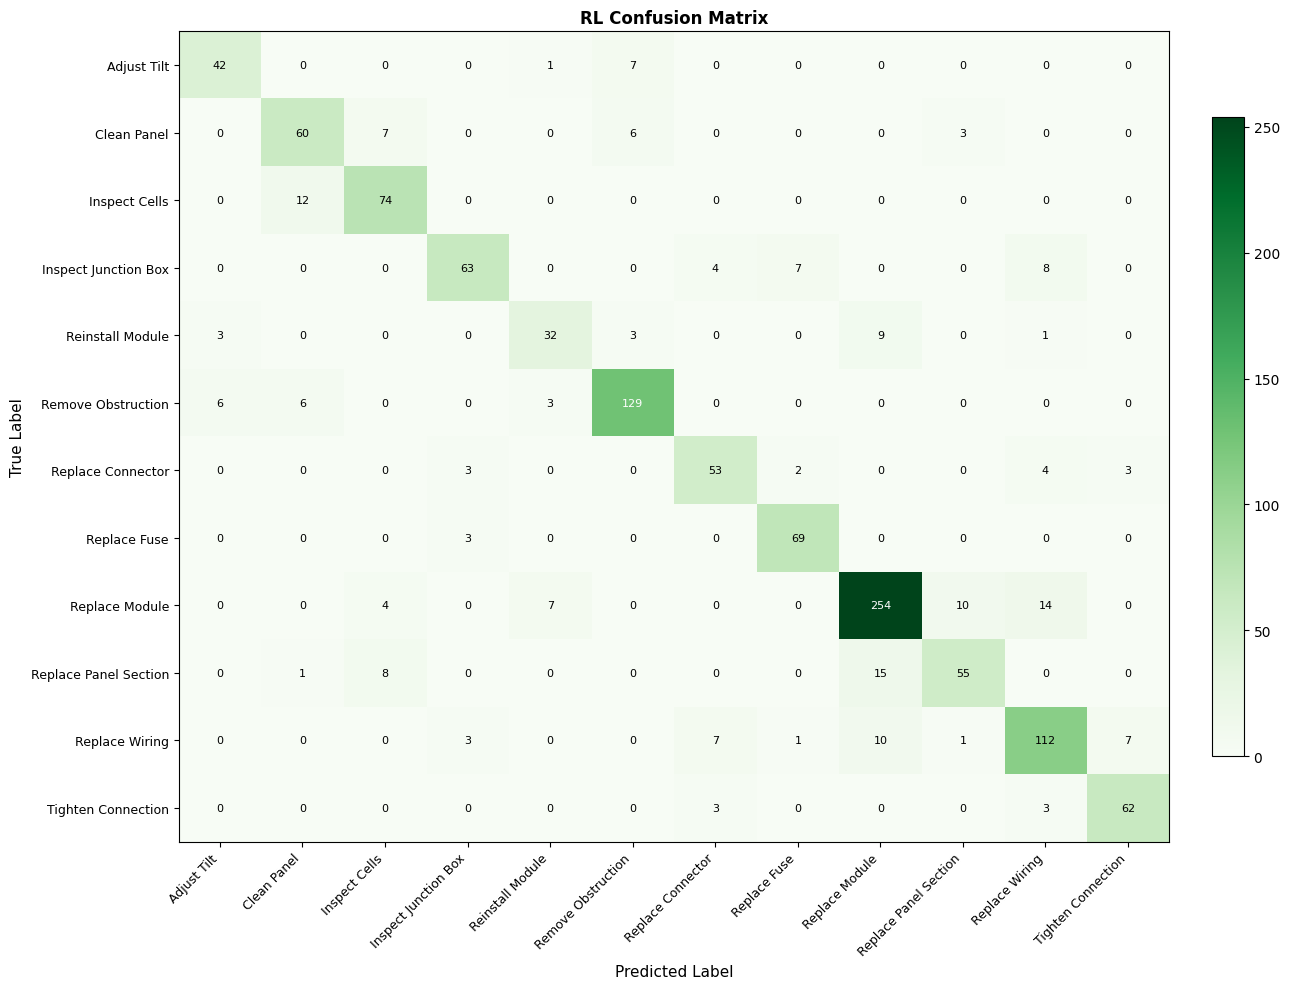

In [13]:
# RL Classification Report

print("RL Model — Classification Report\n")
print(classification_report(y_test, rl_preds))


# Plot RL Training Convergence

eps_range = list(range(1, N_EPISODES + 1))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(eps_range, episode_rewards, "o-", color="#2166ac", lw=2, ms=6)
ax.fill_between(eps_range, episode_rewards, alpha=0.15, color="#2166ac")
ax.set_xlabel("Episode"); ax.set_ylabel("Average Reward")
ax.set_title("Q-Learning: Reward Convergence", fontweight="bold")
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(eps_range, [a * 100 for a in episode_accs], "s-", color="#4dac26", lw=2, ms=6)
ax2.fill_between(eps_range, [a * 100 for a in episode_accs], alpha=0.15, color="#4dac26")
ax2.axhline(rf_acc * 100, color="#d01c8b", lw=1.5, ls="--",
            label=f"RF baseline ({rf_acc:.1%})")
ax2.set_xlabel("Episode"); ax2.set_ylabel("Training Accuracy (%)")
ax2.set_title("Q-Learning: Accuracy per Episode", fontweight="bold")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("RL Agent Training  |  Cost & Downtime",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Plot Cost & Downtime Comparison (RF vs RL)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["RF Only", "RF + RL"]
colors = ["#4393c3", "#2ca25f"]

ax = axes[0]
bars = ax.bar(labels, [rf_total_cost, total_cost], color=colors, width=0.5, edgecolor="white")
for bar, val in zip(bars, [rf_total_cost, total_cost]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f"${val:,.0f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Total Repair Cost ($)")
ax.set_title(f"Total Repair Cost: ${rf_total_cost-total_cost:,.0f}", fontweight="bold")
ax.set_ylim(0, max(rf_total_cost, total_cost) * 1.18)
ax.grid(axis="y", alpha=0.3)
ax.text(0.5, 0.04, "Avg Repair_Cost per action",
        transform=ax.transAxes, ha="center", fontsize=8, color="gray")

ax2 = axes[1]
bars2 = ax2.bar(labels, [rf_total_down, total_down], color=colors, width=0.5, edgecolor="white")
for bar, val in zip(bars2, [rf_total_down, total_down]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"{val:.1f} hrs", ha="center", fontsize=11, fontweight="bold")
ax2.set_ylabel("Total Downtime (hours)")
ax2.set_title(f"Total Downtime: {rf_total_down-total_down:.1f} hrs", fontweight="bold")
ax2.set_ylim(0, max(rf_total_down, total_down) * 1.18)
ax2.grid(axis="y", alpha=0.3)
ax2.text(0.5, 0.04, "Avg Downtime_Hours per action",
         transform=ax2.transAxes, ha="center", fontsize=8, color="gray")

plt.suptitle("RF Only vs RF + RL ",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# Plot Real Cost & Downtime per Action

actions_sorted = sorted(action_records.keys(),
                        key=lambda a: action_records[a]["cost_mean"])
cost_means = [action_records[a]["cost_mean"] for a in actions_sorted]
down_means = [action_records[a]["down_mean"] for a in actions_sorted]
counts     = [action_records[a]["count"]     for a in actions_sorted]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
bars = ax.barh(actions_sorted, cost_means,
               color=plt.cm.Blues(np.linspace(0.4, 0.9, len(actions_sorted))),
               edgecolor="white")
for bar, val, cnt in zip(bars, cost_means, counts):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f"${val:.0f}  (n={cnt})", va="center", fontsize=8)
ax.set_xlabel("Average Repair Cost ($)")
ax.set_title("Avg Repair Cost per Action\n", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, max(cost_means) * 1.38)

ax2 = axes[1]
bars2 = ax2.barh(actions_sorted, down_means,
                 color=plt.cm.Greens(np.linspace(0.4, 0.9, len(actions_sorted))),
                 edgecolor="white")
for bar, val in zip(bars2, down_means):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f"{val:.2f} hrs", va="center", fontsize=8)
ax2.set_xlabel("Average Downtime (hours)")
ax2.set_title("Avg Downtime per Action\n", fontweight="bold")
ax2.grid(axis="x", alpha=0.3)
ax2.set_xlim(0, max(down_means) * 1.38)

plt.tight_layout()
plt.show()

# Plot RL Confusion Matrix

cm_rl = confusion_matrix(y_test, rl_preds, labels=classes)
fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(cm_rl, cmap="Greens", aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(classes)))
ax.set_yticklabels(classes, fontsize=9)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.set_title(f"RL Confusion Matrix",
             fontsize=12, fontweight="bold")
thresh = cm_rl.max() / 2
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm_rl[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm_rl[i, j] > thresh else "black")
plt.tight_layout()
plt.show()


Saving the models to google drive

In [14]:
RF_MODEL_PATH       = f"{DRIVE_FOLDER}/rf_model.pkl"
Q_TABLE_PATH        = f"{DRIVE_FOLDER}/q_table.pkl"
ACTION_RECORDS_PATH = f"{DRIVE_FOLDER}/action_records.pkl"

joblib.dump(rf_pipeline,    RF_MODEL_PATH)
joblib.dump(Q,              Q_TABLE_PATH)
joblib.dump(action_records, ACTION_RECORDS_PATH)

print("All models saved to Google Drive:")
print(f"  RF Model       → {RF_MODEL_PATH}")
print(f"  Q-Table        → {Q_TABLE_PATH}")
print(f"  Action Records → {ACTION_RECORDS_PATH}")


All models saved to Google Drive:
  RF Model       → /content/drive/MyDrive/SolarPV_Rectification/rf_model.pkl
  Q-Table        → /content/drive/MyDrive/SolarPV_Rectification/q_table.pkl
  Action Records → /content/drive/MyDrive/SolarPV_Rectification/action_records.pkl


Example Prediction (Load Models & Predict)

In [15]:
# Load models from Drive
rf_loaded      = joblib.load(RF_MODEL_PATH)
Q_loaded       = joblib.load(Q_TABLE_PATH)
ar_loaded      = joblib.load(ACTION_RECORDS_PATH)
classes_loaded = rf_loaded.classes_

# New fault input
sample = pd.DataFrame({
    "Fault_Type":        ["Open Circuit"],
    "Severity_Level":    ["High"],
    "String_Num":        [9],
    "Panel_Num":         [14],
    "Weather_Condition": ["Rainy"],
    "Irradiance":        [430],
    "Module_Age_Years":  [11],
})

# Step 1: RF gives top-3
probs    = rf_loaded.predict_proba(sample)[0]
top3_idx = np.argsort(probs)[-3:][::-1]
top3     = [classes_loaded[j] for j in top3_idx]

# Step 2: RL picks best
state    = (sample["Fault_Type"].iloc[0], sample["Severity_Level"].iloc[0],
            top3[0], top3[1], top3[2])
q_vals   = {a: Q_loaded.get((state, a), 0.0) for a in top3}
rl_final = max(q_vals, key=q_vals.get)


print("═" * 60)
print("  EXAMPLE PREDICTION")
print("═" * 60)

print(
    f"\n  Input: "
    f"Fault_Type={sample['Fault_Type'].iloc[0]} | "
    f"Severity_Level={sample['Severity_Level'].iloc[0]} | "
    f"String_Num={sample['String_Num'].iloc[0]} | "
    f"Panel_Num={sample['Panel_Num'].iloc[0]} | "
    f"Weather_Condition={sample['Weather_Condition'].iloc[0]} | "
    f"Irradiance={sample['Irradiance'].iloc[0]} W/m² | "
    f"Module_Age_Years={sample['Module_Age_Years'].iloc[0]} yrs"
)

print("\n  RF Top-3 Recommendations:")
for rank, (action, idx) in enumerate(zip(top3, top3_idx), 1):
    cost = ar_loaded[action]["cost_mean"]
    down = ar_loaded[action]["down_mean"]
    print(f"    {rank}. {action:<28}  {probs[idx]*100:5.1f}% ")
    print(f"       Avg Cost: ${cost:.2f}  |  Avg Downtime: {down:.2f} hrs")

print(f"\n  RL Final Selection  →  {rl_final}")
print(f"     Avg Repair Cost  : ${ar_loaded[rl_final]['cost_mean']:.2f}")
print(f"     Avg Downtime     : {ar_loaded[rl_final]['down_mean']:.2f} hrs")

════════════════════════════════════════════════════════════
  EXAMPLE PREDICTION
════════════════════════════════════════════════════════════

  Input: Fault_Type=Open Circuit | Severity_Level=High | String_Num=9 | Panel_Num=14 | Weather_Condition=Rainy | Irradiance=430 W/m² | Module_Age_Years=11 yrs

  RF Top-3 Recommendations:
    1. Replace Wiring                 52.5% 
       Avg Cost: $149.57  |  Avg Downtime: 2.00 hrs
    2. Inspect Junction Box           28.4% 
       Avg Cost: $69.74  |  Avg Downtime: 1.00 hrs
    3. Replace Connector              13.2% 
       Avg Cost: $89.93  |  Avg Downtime: 0.99 hrs

  RL Final Selection  →  Replace Wiring
     Avg Repair Cost  : $149.57
     Avg Downtime     : 2.00 hrs
